# Level 3 - Task 1: Predictive Modeling (Classification)
## Codveda Technologies Data Analysis Internship
**Problem:** Customer Churn Prediction

In [1]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================
# 2. Load Dataset
# ============================
df = pd.read_csv('/workspaces/codveda_technologies-data_analysis_internship/data/raw/churn-bigml-20.csv')

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nTarget Variable Distribution:")
print(df['Churn'].value_counts())

Dataset Shape: (667, 20)

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False



Target Variable Distribution:
Churn
False    572
True      95
Name: count, dtype: int64


In [3]:
# ============================
# 3. Data Preprocessing
# ============================
# Create copy
df_clean = df.copy()

# Convert boolean target to integer
df_clean['Churn'] = df_clean['Churn'].astype(int)

# Encode categorical variables
categorical_cols = ['State', 'International plan', 'Voice mail plan']
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le

print("Categorical variables encoded")
print(df_clean[['International plan', 'Voice mail plan', 'Churn']].head())

Categorical variables encoded
   International plan  Voice mail plan  Churn
0                   0                0      0
1                   0                0      1
2                   0                0      1
3                   0                0      0
4                   0                0      0


In [4]:
# ============================
# 4. Feature Selection & Scaling
# ============================
# Define features and target
feature_cols = [col for col in df_clean.columns if col != 'Churn']
X = df_clean[feature_cols]
y = df_clean['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 533 samples
Test set: 134 samples


In [5]:
# ============================
# 5. Model Training & Evaluation
# ============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))

# Summary Table
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
display(results_df.sort_values('F1-Score', ascending=False))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       115
           1       0.50      0.16      0.24        19

    accuracy                           0.86       134
   macro avg       0.69      0.57      0.58       134
weighted avg       0.82      0.86      0.83       134


Decision Tree Results:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       115
           1       0.85      0.58      0.69        19

    accuracy                           0.93       134
   macro avg       0.89      0.78      0.82       134
weighted avg       0.92      0.93      0.92       134




Random Forest Results:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       115
           1       1.00      0.47      0.64        19

    accuracy                           0.93       134
   macro avg       0.96      0.74      0.80       134
weighted avg       0.93      0.93      0.91       134


MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.9254,0.8462,0.5789,0.6875
2,Random Forest,0.9254,1.0000,0.4737,0.6429
0,Logistic Regression,0.8582,0.5000,0.1579,0.2400


In [6]:
# ============================
# 6. Hyperparameter Tuning (Random Forest)
# ============================
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1-Score:", round(grid_search.best_score_, 4))

# Final Model
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

print("\nFinal Tuned Random Forest Performance:")
print(classification_report(y_test, y_pred_final))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score: 0.6008

Final Tuned Random Forest Performance:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       115
           1       0.90      0.47      0.62        19

    accuracy                           0.92       134
   macro avg       0.91      0.73      0.79       134
weighted avg       0.92      0.92      0.91       134



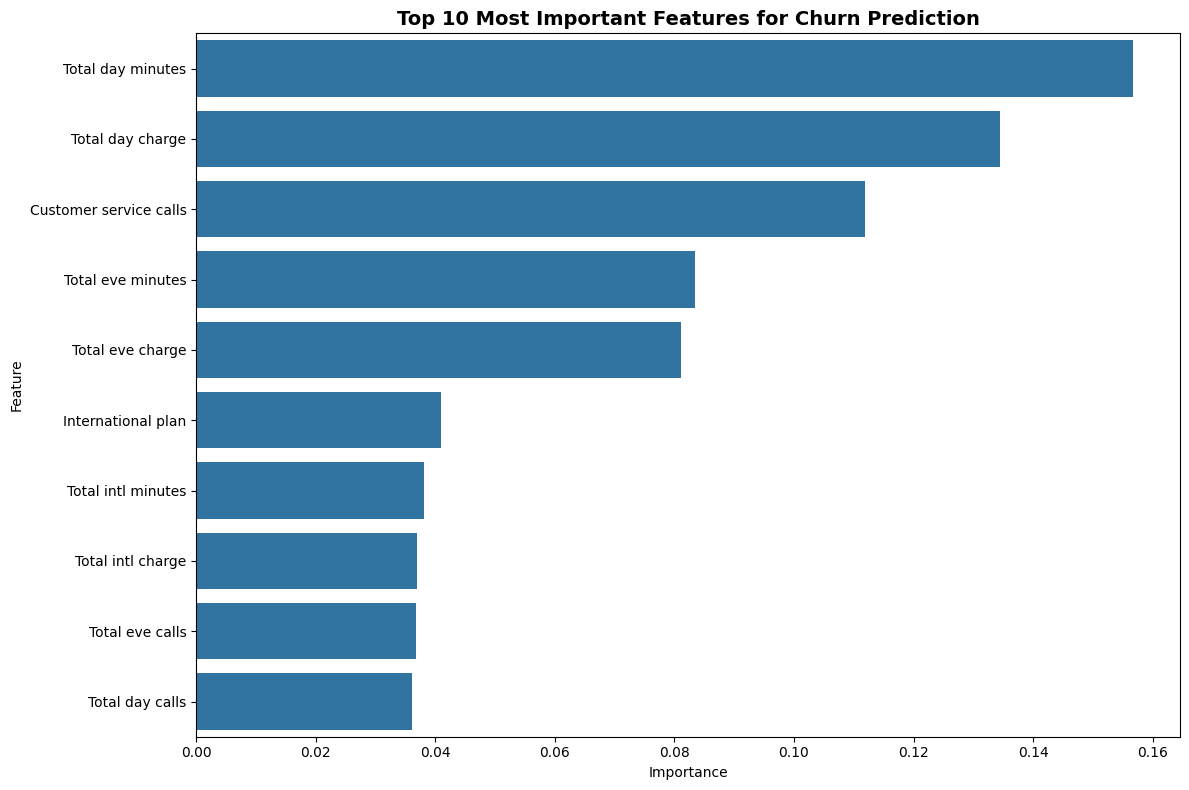

In [7]:
# ============================
# 7. Feature Importance
# ============================
importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features for Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspaces/codveda_technologies-data_analysis_internship/visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ============================
# 8. Final Insights & Recommendations
# ============================
print("="*80)
print("CHURN PREDICTION - FINAL INSIGHTS")
print("="*80)
print("• Best Model: Random Forest (after tuning)")
print(f"• Best F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print("• Most Important Features: Customer Service Calls, Total Day Minutes, International Plan")
print("\nBusiness Recommendations:")
print("1. Focus on customers with high Customer Service Calls")
print("2. Review International Plan pricing")
print("3. Monitor customers with high daytime usage")
print("4. Implement retention strategies for high-risk customers")
print("="*80)

CHURN PREDICTION - FINAL INSIGHTS
• Best Model: Random Forest (after tuning)
• Best F1-Score: 0.6207
• Most Important Features: Customer Service Calls, Total Day Minutes, International Plan

Business Recommendations:
1. Focus on customers with high Customer Service Calls
2. Review International Plan pricing
3. Monitor customers with high daytime usage
4. Implement retention strategies for high-risk customers
